**Dataset Upload and Inspection**

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
player_weekly = pd.read_csv('/content/drive/MyDrive/Spring 26/BA576/BA576 Project 1/NFL-stats/weekly_player_stats_offense.csv', delimiter=',')

In [59]:
player_weekly.shape

(76287, 678)

In [60]:
player_weekly.head(10)

,player_id,pfr_player_id,player_name,position,position_group,team,birth_date,height,weight,college_name,...,cum_first_down_rush,cum_third_down_converted,cum_third_down_failed,cum_fourth_down_converted,cum_fourth_down_failed,cum_safety,cum_tackled_for_loss,cum_fantasy_points_standard,cum_fantasy_points_half_ppr,cum_fantasy_points_ppr
0,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.6,2.1,2.6
1,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,1.0,0.0,1.0,0.0,0.0,0.0,2.0,1.5,2.0,2.5
2,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,1.0,0.0,1.0,0.0,0.0,0.0,2.0,3.4,4.9,6.4
3,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,3.0,0.0,1.0,0.0,0.0,0.0,2.0,7.7,9.2,10.7
4,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,3.0,0.0,2.0,0.0,0.0,0.0,2.0,10.7,14.2,17.7
5,00-0038389,AbanIs00,Israel Abanikanda,RB,RB,NYJ,2002-10-05,70.0,216.0,Pittsburgh,...,3.0,0.0,2.0,0.0,0.0,0.0,3.0,11.3,14.8,18.3
6,00-0031021,AbbrJa00,Jared Abbrederis,WR,WR,DET,1990-12-17,73.0,195.0,Wisconsin,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.7,4.7,5.7
7,00-0031021,AbbrJa00,Jared Abbrederis,WR,WR,DET,1990-12-17,73.0,195.0,Wisconsin,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,4.4,5.9,7.4
8,00-0031021,AbbrJa00,Jared Abbrederis,WR,WR,GB,1990-12-17,73.0,195.0,Wisconsin,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.4,2.4,3.4
9,00-0031021,AbbrJa00,Jared Abbrederis,WR,WR,GB,1990-12-17,73.0,195.0,Wisconsin,...,0.0,3.0,5.0,0.0,0.0,0.0,0.0,4.9,7.9,10.9


In [61]:
player_weekly.dtypes.unique()

array([dtype('O'), dtype('float64'), dtype('int64')], dtype=object)

**Data Cleaning**

In [62]:
fantasy_features = []
for feature in player_weekly.columns:
  if "fantasy" in feature:
    fantasy_features.append(feature)
fantasy_features
fantasy_features.remove('fantasy_points_standard')

In [63]:
# Drop all other fantasy information since fantasy_points_standard is main outcome variable
player_weekly = player_weekly.drop(fantasy_features, axis=1)

In [64]:
y = player_weekly['fantasy_points_standard']

In [65]:
player_weekly.shape

(76287, 649)

In [66]:
# Remove unnecessary player info, since we can access players by id which is primary key
player_weekly = player_weekly.drop(['pfr_player_id', 'player_name'], axis=1)

In [67]:
player_weekly.shape

(76287, 647)

**Descriptive Analytics**

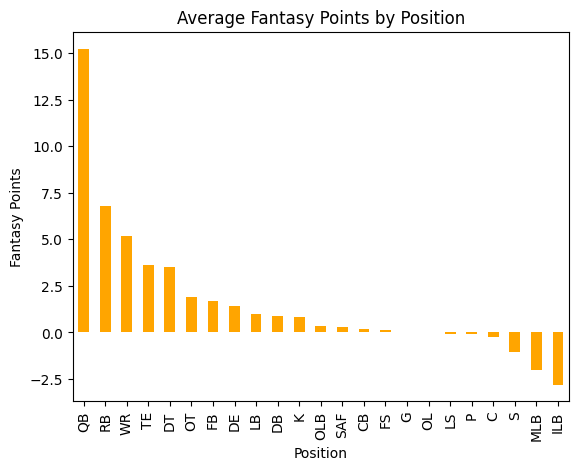

In [68]:
# Fantasy points grouped by position
position_points = player_weekly.groupby('position')['fantasy_points_standard'].mean()
position_points = position_points.sort_values(ascending=False)

position_points.plot(kind = 'bar', color = 'orange')
plt.title('Average Fantasy Points by Position')
plt.xlabel('Position')
plt.ylabel('Fantasy Points')
plt.show()

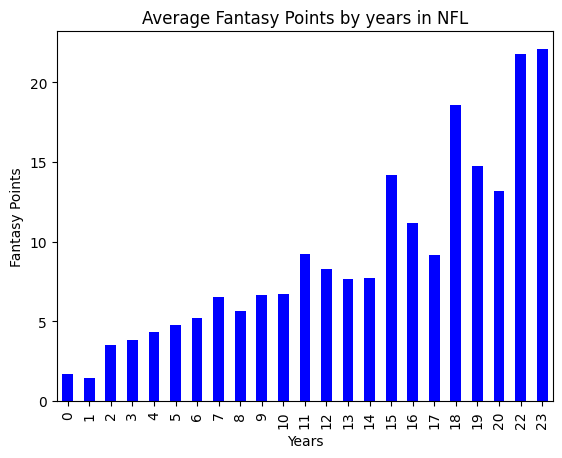

In [69]:
# Fantasy points grouped by experience in years
points_by_year = player_weekly.groupby('years_exp')['fantasy_points_standard'].mean()

points_by_year.plot(kind = 'bar', color = 'blue')
plt.title('Average Fantasy Points by years in NFL')
plt.xlabel('Years')
plt.ylabel('Fantasy Points')
plt.show()

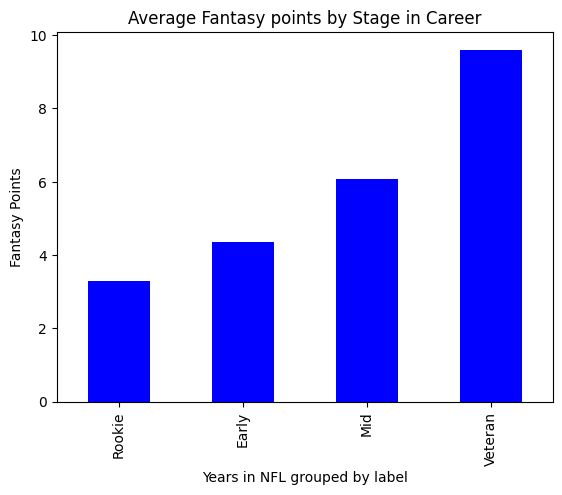

In [70]:
# Years experience put into bins
# Rookie: years 1-2
# Early: years 3-5
# Mid: years 6-10
# Veteran: years 11-20
bins = [0, 2, 5, 10, 20]
labels = ['Rookie', 'Early', 'Mid', 'Veteran']
player_weekly['exp_group'] = pd.cut(player_weekly['years_exp'], bins=bins, labels=labels)

exp_points = player_weekly.groupby('exp_group')['fantasy_points_standard'].mean()
exp_points.plot(kind = 'bar', color = 'blue')

plt.title('Average Fantasy points by Stage in Career')
plt.xlabel('Years in NFL grouped by label')
plt.ylabel('Fantasy Points')
plt.show()

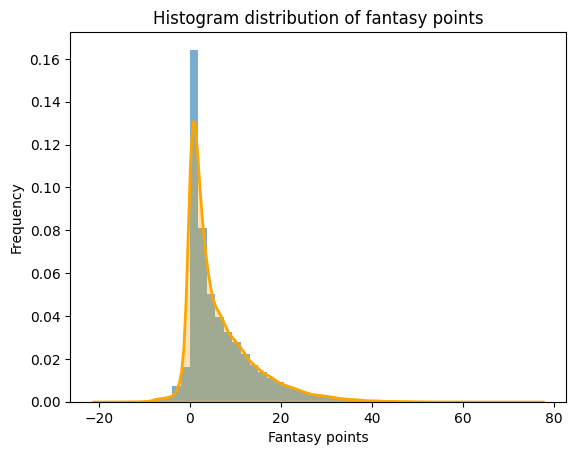

In [71]:
# Histogram distribution of fantasy points
import seaborn as sns
plt.hist(player_weekly['fantasy_points_standard'], bins = 50,  density = True, alpha = 0.6)
sns.kdeplot(player_weekly['fantasy_points_standard'], color='orange', linewidth=2, fill = True, alpha= 0.3)

plt.title('Histogram distribution of fantasy points')
plt.xlabel('Fantasy points')
plt.ylabel('Frequency')
plt.show()

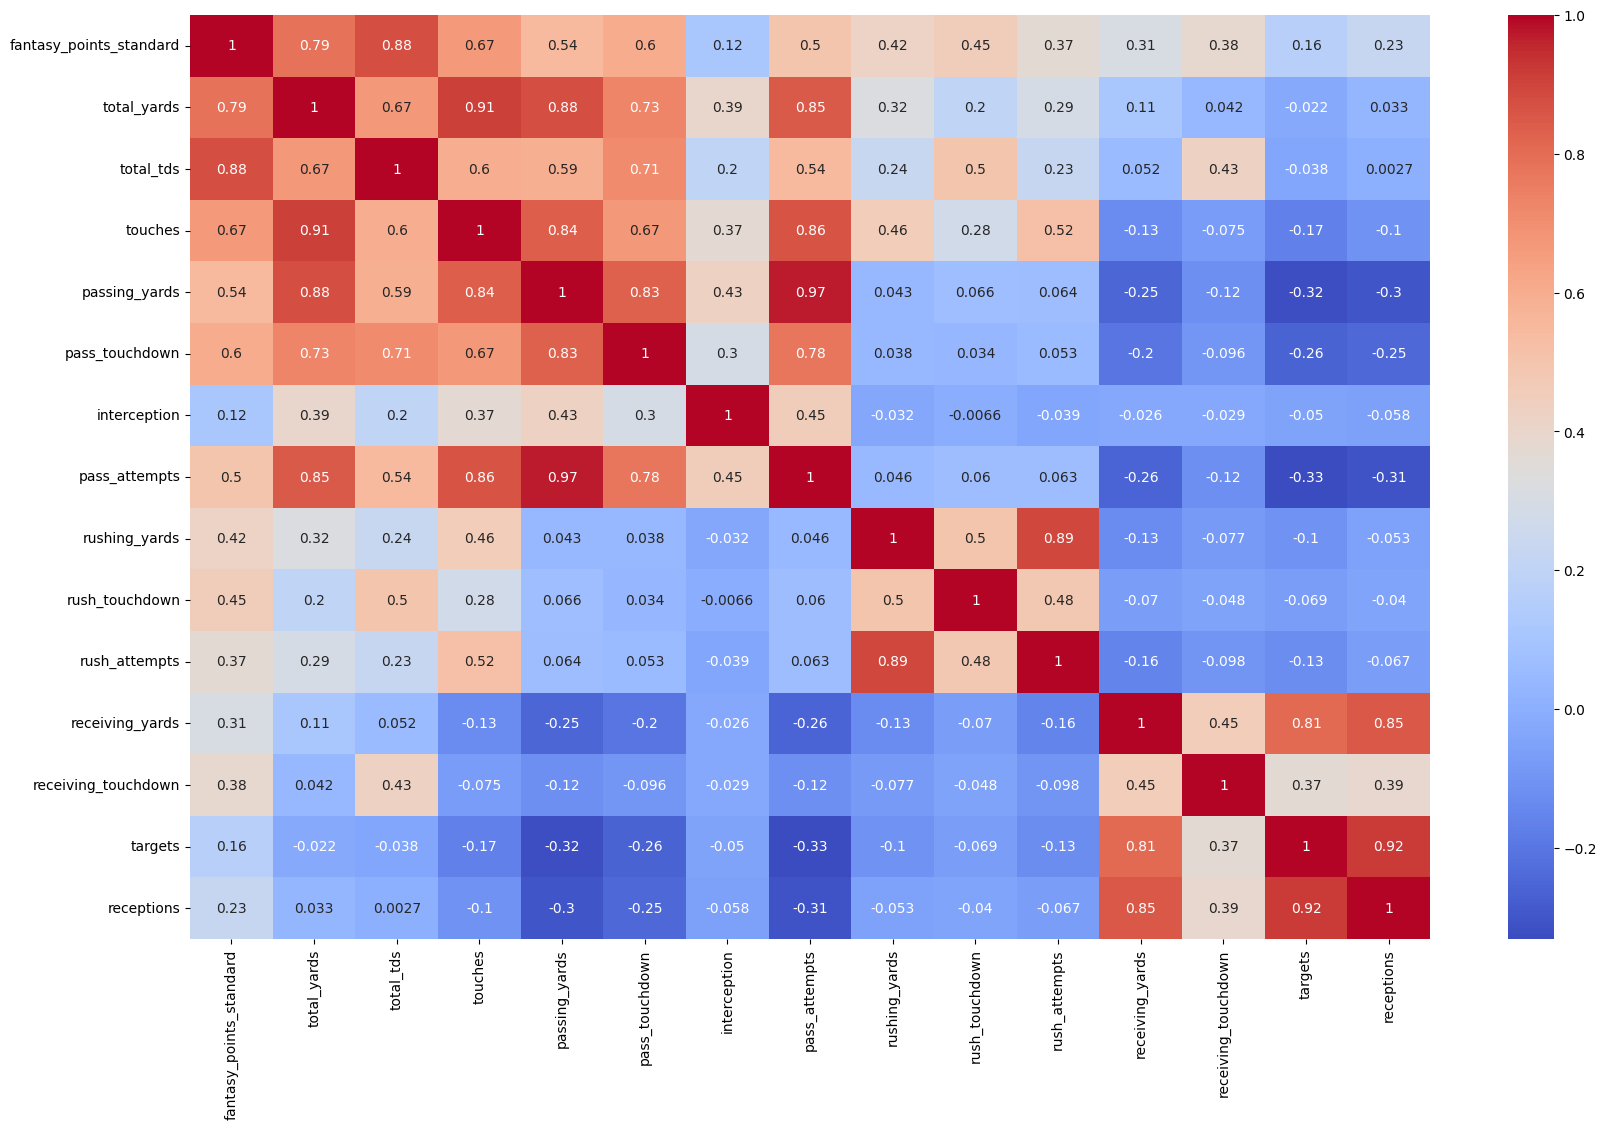

In [72]:
# Correlation heatmap
# Pick only columns I want to explore since doing a heatmap on everything would be too big and too computationally expensive

# Fantasy points are heavily correlated with yards and touchdowns, makes sense
cols = [
    'fantasy_points_standard',
    'total_yards',
    'total_tds',
    'touches',

    'passing_yards',
    'pass_touchdown',
    'interception',
    'pass_attempts',

    'rushing_yards',
    'rush_touchdown',
    'rush_attempts',

    'receiving_yards',
    'receiving_touchdown',
    'targets',
    'receptions'
]

corr = player_weekly[cols].corr(numeric_only= True)
plt.figure(figsize=(20, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

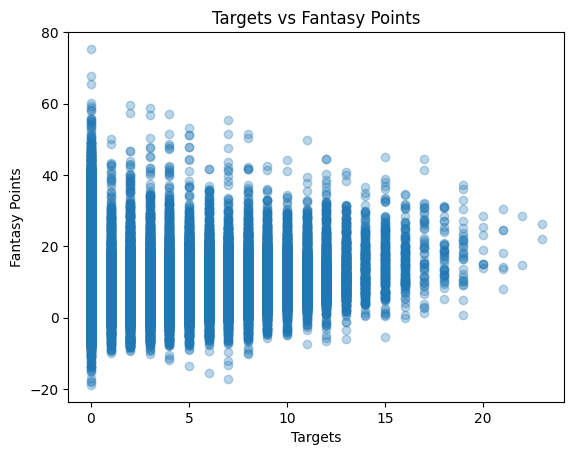

In [73]:
# Targets vs fantasy points
# Volume of targets doesn't gaurantee points, it averages out to a mean of around y = 20
plt.scatter(player_weekly['targets'], player_weekly['fantasy_points_standard'], alpha=0.3)
plt.xlabel('Targets')
plt.ylabel('Fantasy Points')
plt.title('Targets vs Fantasy Points')
plt.show()

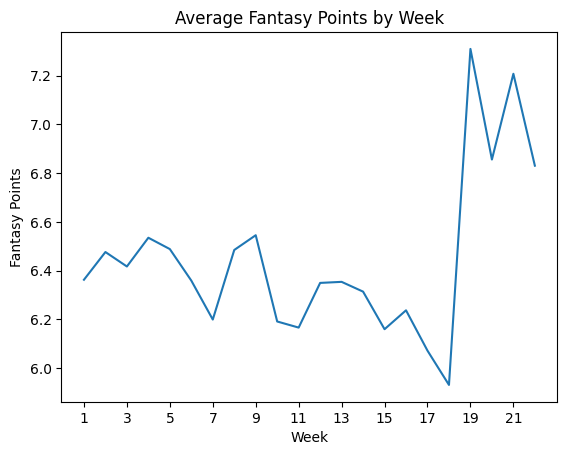

In [74]:
# Does fantasy points change by week?
# Points are relatively stable, games are much more competitive in week 18 and much less competitive in week 19
weekly_avg = player_weekly.groupby('week')['fantasy_points_standard'].mean()

weeks = weekly_avg.index
plt.xticks(np.arange(min(weeks), max(weeks) + 1, 2))
weekly_avg.plot()
plt.title('Average Fantasy Points by Week')
plt.xlabel('Week')
plt.ylabel('Fantasy Points')
plt.show()

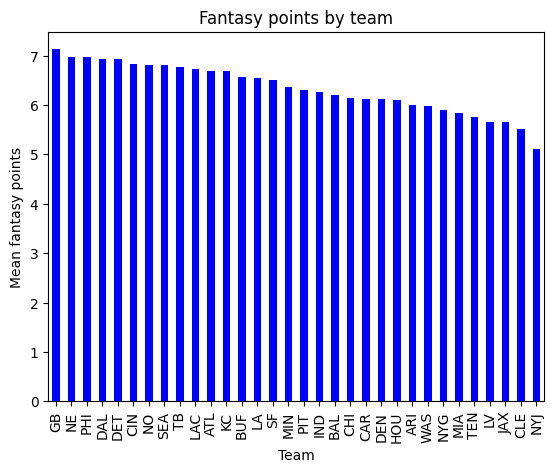

<Figure size 4000x1000 with 0 Axes>

In [75]:
# Does team make an impact?
team_means = player_weekly.groupby('team')['fantasy_points_standard'].mean().sort_values(ascending = False)
team_means.plot(kind = "bar", color = "blue")
plt.title('Fantasy points by team')
plt.xlabel('Team')
plt.ylabel('Mean fantasy points')
plt.figure(figsize=(40, 10))
plt.show()

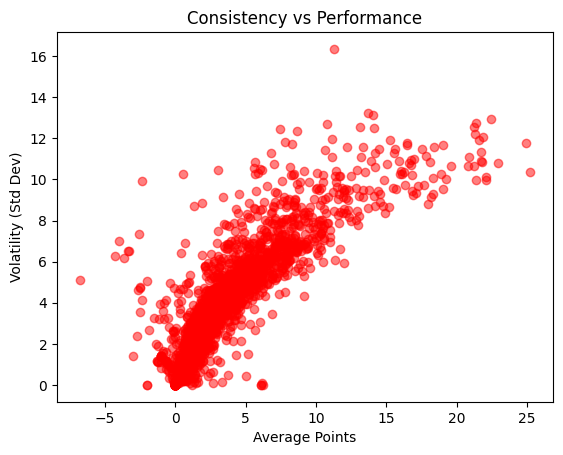

In [76]:
# Any volatility in fantasy points?
# there are a few outliers
player_stats = player_weekly.groupby('player_id')['fantasy_points_standard'].agg(['mean','std'])

plt.scatter(player_stats['mean'], player_stats['std'], alpha=0.5, color = "red")
plt.xlabel('Average Points')
plt.ylabel('Volatility (Std Dev)')
plt.title('Consistency vs Performance')
plt.show()

**Train-Test Split**

In [77]:
model_df = player_weekly.copy()

In [78]:
base_cols = model_df.iloc[:, 0:15].select_dtypes(include=['number']).columns.tolist()
len(base_cols)

7

In [79]:
# Sort by player and time
model_df = model_df.sort_values(['player_id', 'season', 'week'])

# Create next-week target
model_df['target_next_week'] = (
    model_df.groupby('player_id')['fantasy_points_standard'].shift(-1)
)

In [80]:
# Drop potentially leaky columns
predictors = model_df.drop('fantasy_points_standard', axis=1)
rolling_cols = predictors.select_dtypes(include=['number']).drop(columns=base_cols)

bad = ["cum", "trend", "avg", "z_score"]
for col in rolling_cols.columns:
    for word in bad:
        if word in col:
            rolling_cols = rolling_cols.drop(columns=col)
            break

In [81]:
rolling_cols = rolling_cols.columns

In [82]:
len(rolling_cols)

69

In [83]:
windows = [3, 5, 8]

for col in rolling_cols:
    for w in windows:
        model_df[f'{col}_rolling{w}'] = (
            model_df.groupby('player_id')[col]
            .transform(lambda x: x.shift(1).rolling(window=w, min_periods=1).mean())
        )

In [84]:
rolling_feature_cols = [
    col for col in model_df.columns
    if '_rolling3' in col or '_rolling5' in col or '_rolling8' in col
]

In [85]:
feature_cols = base_cols + rolling_feature_cols

In [86]:
model_df['target_next_week'] = (
    model_df.groupby('player_id')['fantasy_points_standard'].shift(-1)
)

In [87]:
# Drop entries with null values since player did not play that game
model_df = model_df.dropna()

In [88]:
model_X = model_df[feature_cols].copy()
model_y = model_df['target_next_week'].copy()

In [89]:
latest_season = model_df['season'].max()
week_cutoff = 12

model_train_idx = (
    (model_df['season'] < latest_season) |
    ((model_df['season'] == latest_season) & (model_df['week'] < week_cutoff))
)

model_test_idx = (
    (model_df['season'] == latest_season) & (model_df['week'] >= week_cutoff)
)

X_train = model_X.loc[model_train_idx]
X_test = model_X.loc[model_test_idx]
y_train = model_y.loc[model_train_idx]
y_test = model_y.loc[model_test_idx]

In [90]:
model_df.shape

(46110, 856)

**Feature Engineering**


In [91]:
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer, RobustScaler
from sklearn.impute import SimpleImputer

# Strip whitespace from column names to prevent KeyError due to hidden characters
model_df.columns = model_df.columns.str.strip()

# Efficiency ratios
if "total_yards" in model_df.columns and "touches" in model_df.columns:
  model_df["yards_per_touch"] = model_df["total_yards"] / model_df["touches"].replace(0, np.nan)
if "total_tds" in model_df.columns and "touches" in model_df.columns:
  model_df["tds_per_touch"] = model_df["total_tds"] / model_df["touches"].replace(0, np.nan)
if "receptions" in model_df.columns and "targets" in model_df.columns:
  model_df["catch_rate"] = model_df["receptions"] / model_df["targets"].replace(0, np.nan)
if "receiving_yards" in model_df.columns and "targets" in model_df.columns:
  model_df["yards_per_target"] = model_df["receiving_yards"] / model_df["targets"].replace(0, np.nan)

  # Lagged prior-week fantasy points (very predictive, still leakage-safe because shifted)
  if "fantasy_points_standard" in model_df.columns:
    model_df["fp_lag1"] = (
      model_df.groupby(["player_id", "season"], sort=False)["fantasy_points_standard"]\
        .transform(lambda s: s.shift(1))
    )
    model_df["fp_roll2"] = (
      model_df.groupby(["player_id", "season"], sort=False)["fantasy_points_standard"]\
        .transform(lambda s: s.shift(1).rolling(window=2, min_periods=1).mean())
    )

**Baseline Model**

In [92]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error

player_means = (
    model_df[model_train_idx]
    .groupby('player_id')['fantasy_points_standard']
    .mean()
)

test_players = model_df[model_test_idx]['player_id']
known_mask = test_players.isin(player_means.index)

X_test = X_test[known_mask.values]
y_test = y_test[known_mask.values]

baseline_pred = (
    model_df.groupby('player_id')['fantasy_points_standard']
    .transform(lambda x: x.shift(1).expanding().mean())
)

baseline_train_preds = baseline_pred[model_train_idx]
baseline_test_preds  = baseline_pred[model_test_idx].loc[known_mask[known_mask].index]

train_valid = baseline_train_preds.notna()
test_valid  = baseline_test_preds.notna()

X_train = X_train[train_valid]
y_train = y_train[train_valid]
X_test = X_test[test_valid]
y_test = y_test[test_valid]

baseline_train_preds = baseline_train_preds[train_valid]
baseline_test_preds = baseline_test_preds[test_valid]

print(f'Baseline RMSE (train): {rmse(y_train, baseline_train_preds):.4f}')
print(f'Baseline RMSE (test):  {rmse(y_test, baseline_test_preds):.4f}')

Baseline RMSE (train): 6.9800
Baseline RMSE (test):  6.9535


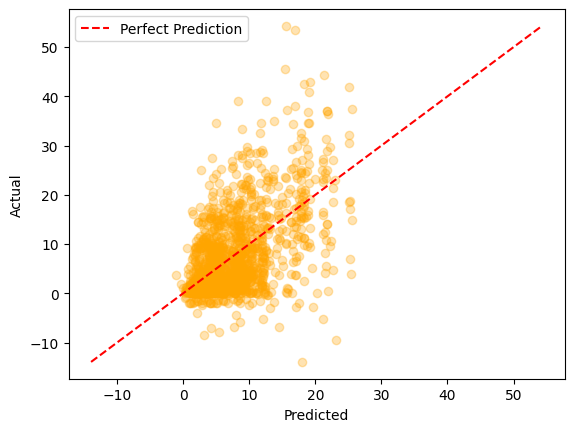

In [93]:
plt.scatter(x = baseline_test_preds, y = y_test, alpha=0.3, c='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.legend()

**Ridge Regression Model**

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

ridge_params = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    error_score='raise'
)

ridge_grid.fit(X_train, y_train)

ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R^2:", ridge_r2)

Best Ridge alpha: {'ridge__alpha': 100}
Ridge RMSE: 6.659887821199629
Ridge MAE: 4.612552452794544
Ridge R^2: 0.3550742340304862


In [95]:
#ridge by pos
positions = ['QB', 'RB', 'WR', 'TE']

ridge_results_by_pos = []

for pos in positions:
    print(f"\n--- Position: {pos} ---")

    # Filter ds by position
    pos_idx = model_df['position'] == pos

    pos_train_idx = model_train_idx & pos_idx
    pos_test_idx = model_test_idx & pos_idx

    X_train_pos = model_X.loc[pos_train_idx].copy()
    X_test_pos = model_X.loc[pos_test_idx].copy()
    y_train_pos = model_y.loc[pos_train_idx]
    y_test_pos = model_y.loc[pos_test_idx]

    print("Train size:", X_train_pos.shape[0])
    print("Test size:", X_test_pos.shape[0])

    # Remove position dummies if present
    X_train_pos = X_train_pos.drop(
        columns=[c for c in X_train_pos.columns if 'position_' in c],
        errors='ignore'
    )
    X_test_pos = X_test_pos.drop(
        columns=[c for c in X_test_pos.columns if 'position_' in c],
        errors='ignore'
    )

    # Fit Ridge for this specific position
    ridge_grid.fit(X_train_pos, y_train_pos)

    # Predictions
    train_preds = ridge_grid.predict(X_train_pos)
    test_preds = ridge_grid.predict(X_test_pos)

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_pos, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test_pos, test_preds))

    train_r2 = r2_score(y_train_pos, train_preds)
    test_r2 = r2_score(y_test_pos, test_preds)

    train_mae = mean_absolute_error(y_train_pos, train_preds)
    test_mae = mean_absolute_error(y_test_pos, test_preds)

    print("Best alpha:", ridge_grid.best_params_)
    print("Train RMSE:", train_rmse)
    print("Test RMSE:", test_rmse)
    print("Train R^2:", train_r2)
    print("Test R^2:", test_r2)

    ridge_results_by_pos.append({
        'Position': pos,
        'Best Alpha': ridge_grid.best_params_['ridge__alpha'],
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R^2': train_r2,
        'Test R^2': test_r2,
        'Train MAE': train_mae,
        'Test MAE': test_mae
    })

ridge_pos_df = pd.DataFrame(ridge_results_by_pos)
ridge_pos_df


--- Position: QB ---
Train size: 6716
Test size: 199
Best alpha: {'ridge__alpha': 100}
Train RMSE: 10.300771281280758
Test RMSE: 11.561828173373073
Train R^2: 0.19918536541388698
Test R^2: 0.11603063873048558

--- Position: RB ---
Train size: 10819
Test size: 389
Best alpha: {'ridge__alpha': 100}
Train RMSE: 6.810698969061517
Test RMSE: 7.217952902555247
Train R^2: 0.25680175547761264
Test R^2: 0.18506398310919014

--- Position: WR ---
Train size: 17507
Test size: 622
Best alpha: {'ridge__alpha': 100}
Train RMSE: 5.703582144004398
Test RMSE: 5.2439573787017775
Train R^2: 0.18087983434275268
Test R^2: 0.1926753904103209

--- Position: TE ---
Train size: 8833
Test size: 349
Best alpha: {'ridge__alpha': 100}
Train RMSE: 4.297827501930755
Test RMSE: 4.695200695709692
Train R^2: 0.19192707950713883
Test R^2: 0.05717258675035386


,Position,Best Alpha,Train RMSE,Test RMSE,Train R^2,Test R^2,Train MAE,Test MAE
0,QB,100,10.300771,11.561828,0.199185,0.116031,8.172302,8.961013
1,RB,100,6.810699,7.217953,0.256802,0.185064,5.001100,5.146039
2,WR,100,5.703582,5.243957,0.180880,0.192675,4.281485,3.873720
3,TE,100,4.297828,4.695201,0.191927,0.057173,3.127001,3.265831


Best Ridge alpha: {'ridge__alpha': np.float64(2310.129700083163)}
Ridge RMSE: 6.6496581662037295
Ridge MAE: 4.627558135743827
Ridge R^2: 0.357053937427539


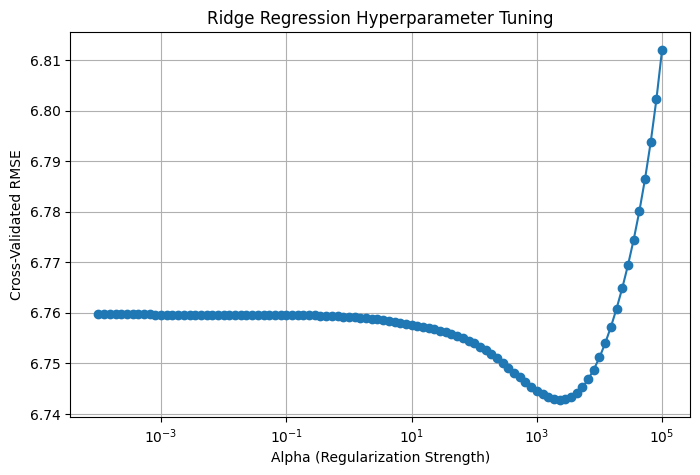

In [96]:
# Tuning
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pipeline
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

# Wide alpha grid (log scale)
ridge_params = {
    'ridge__alpha': np.logspace(-4, 5, 100)
}

# Grid search with CV
ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Fit model
ridge_grid.fit(X_train, y_train)

# Best model + predictions
ridge_best = ridge_grid.best_estimator_
ridge_preds = ridge_best.predict(X_test)

# Metrics
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_preds))
ridge_mae = mean_absolute_error(y_test, ridge_preds)
ridge_r2 = r2_score(y_test, ridge_preds)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R^2:", ridge_r2)

# ==============================
# Plot: Alpha vs RMSE (for presentation)
# ==============================

ridge_results = pd.DataFrame(ridge_grid.cv_results_)
ridge_results['RMSE'] = np.sqrt(-ridge_results['mean_test_score'])

plt.figure(figsize=(8,5))
plt.plot(ridge_results['param_ridge__alpha'], ridge_results['RMSE'], marker='o')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Cross-Validated RMSE')
plt.title('Ridge Regression Hyperparameter Tuning')
plt.grid(True)
plt.show()

**Lasso Model**

In [97]:
# finding best alpha for lasso model
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5)
lasso_cv.fit(X_train, y_train)
best_alpha = lasso_cv.alpha_

In [98]:
print("Best alpha:", lasso_cv.alpha_)

Best alpha: 0.021209508879201904


In [99]:
# lasso with best predictors/alpha
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline

rmse = root_mean_squared_error

scaler = StandardScaler()
lasso_pipe = make_pipeline(scaler, SelectFromModel(Lasso(alpha=best_alpha)), Lasso(alpha=best_alpha))
lasso_pipe.fit(X_train, y_train)
y_pred = lasso_pipe.predict(X_test)

print(f'RMSE on X_train with best predictors (alpha = {best_alpha:0.4f}): {rmse(lasso_pipe.predict(X_train), y_train)}')
print(f'RMSE on X_test with best predictors (alpha = {best_alpha:0.4f}): {rmse(y_pred, y_test)}')
print(f'RMSE of baseline model: {rmse(baseline_test_preds, y_test)}')

RMSE on X_train with best predictors (alpha = 0.0212): 6.716259809553543
RMSE on X_test with best predictors (alpha = 0.0212): 6.652415198339577
RMSE of baseline model: 6.953516188568044


In [100]:
 # absolute difference in RMSE from baseline to lasso model

diff = np.abs(rmse(baseline_test_preds, y_test) - rmse(y_pred, y_test))
print(f'Absolute difference in RMSE from baseline model to fitted lasso model:', diff)

Absolute difference in RMSE from baseline model to fitted lasso model: 0.30110099022846715


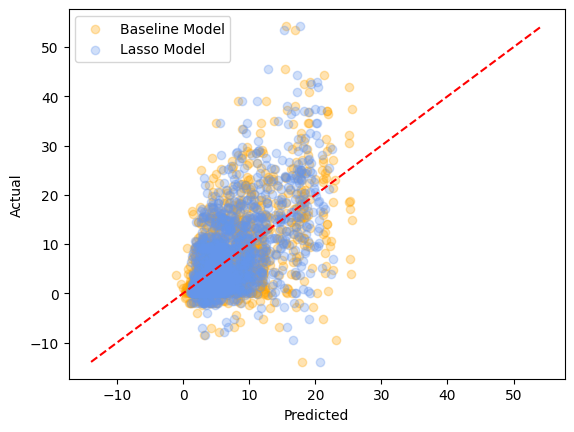

In [101]:
# visualize results
plt.scatter(x = baseline_test_preds, y = y_test, alpha=0.3, c='orange', label='Baseline Model')
plt.scatter(x = y_pred, y = y_test, alpha=0.3, c='cornflowerblue', label='Lasso Model')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.legend()

In [102]:
selector = lasso_pipe.named_steps['selectfrommodel']
mask = selector.get_support()

feature_names = np.array(X_train.columns)[mask]
coefficients = selector.estimator_.coef_[mask]

importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False)

print(importance_df[0:5])

                      feature  coefficient
61  target_next_week_rolling8     1.321788
55       total_yards_rolling8     1.023402
59  target_next_week_rolling3     0.882129
1                  draft_year     0.607361
4                   years_exp     0.564729


In [103]:
len(feature_names)

62

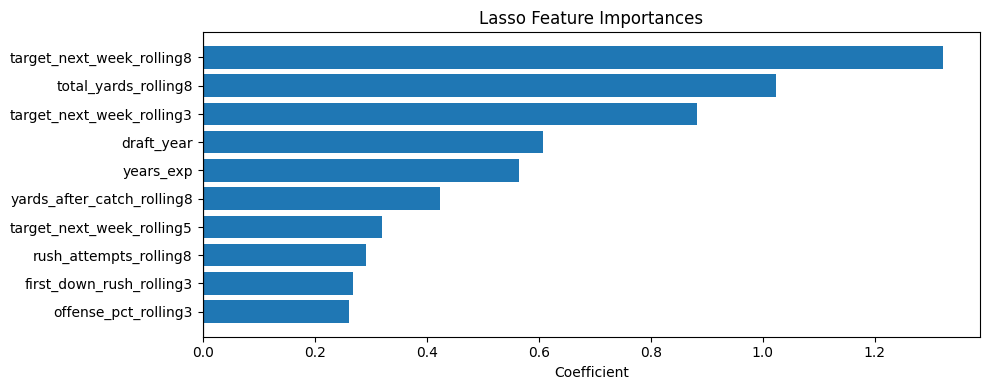

In [104]:
importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', key=abs, ascending=False).head(10)

plt.figure(figsize=(10, len(importance_df) * 0.4))
plt.barh(importance_df['feature'], importance_df['coefficient'])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient')
plt.title('Lasso Feature Importances')
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.show()

In [105]:
selected = lasso_pipe[1].get_support()
feature_names = X_train.columns[selected]
coefs = lasso_pipe[2].coef_
print(sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)[:10])

[('target_next_week_rolling8', np.float64(1.3218355828219523)), ('total_yards_rolling8', np.float64(1.0227068753966526)), ('target_next_week_rolling3', np.float64(0.8821172514072123)), ('draft_year', np.float64(0.605410617373454)), ('years_exp', np.float64(0.5647370079859455)), ('yards_after_catch_rolling8', np.float64(0.42526947682425215)), ('target_next_week_rolling5', np.float64(0.3195969218022667)), ('rush_attempts_rolling8', np.float64(0.2914429413533389)), ('first_down_rush_rolling3', np.float64(0.269145684814846)), ('offense_pct_rolling3', np.float64(0.26072139831262015))]


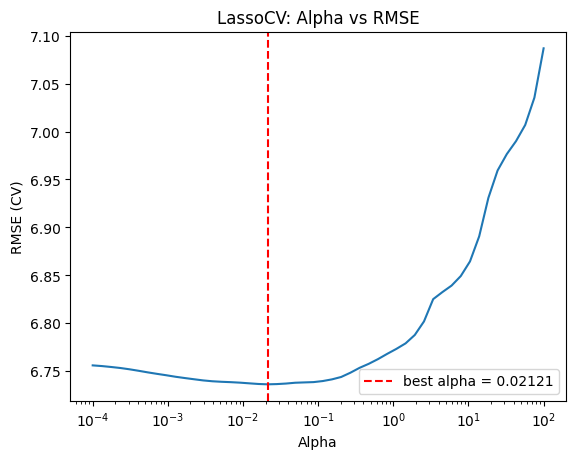

In [106]:
rmse_path = np.sqrt(lasso_cv.mse_path_.mean(axis=1))

plt.plot(lasso_cv.alphas_, rmse_path)
plt.axvline(lasso_cv.alpha_, linestyle='--', color='red', label=f'best alpha = {lasso_cv.alpha_:.5f}')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('RMSE (CV)')
plt.title('LassoCV: Alpha vs RMSE')
plt.legend()
plt.show()

In [107]:
positions = ['QB', 'RB', 'WR', 'TE']
results = {}

for pos in positions:
    pos_mask = model_df['position'] == pos
    pos_data = model_df[pos_mask]

    X_pos = model_X[pos_mask]
    y_pos = model_y[pos_mask]

    train_idx_pos = model_train_idx[pos_mask]
    test_idx_pos  = model_test_idx[pos_mask]

    X_train_pos = X_pos[train_idx_pos]
    X_test_pos  = X_pos[test_idx_pos]
    y_train_pos = y_pos[train_idx_pos]
    y_test_pos  = y_pos[test_idx_pos]

    known_mask_pos = pos_data[test_idx_pos]['player_id'].isin(
        pos_data[train_idx_pos].groupby('player_id')['fantasy_points_standard'].mean().index
    )

    X_test_pos = X_test_pos.loc[known_mask_pos[known_mask_pos].index]
    y_test_pos = y_test_pos.loc[known_mask_pos[known_mask_pos].index]

    baseline_pred_pos = (
        pos_data.groupby('player_id')['fantasy_points_standard']
        .transform(lambda x: x.shift(1).expanding().mean())
    )
    baseline_train_pos = baseline_pred_pos[train_idx_pos]
    baseline_test_pos  = baseline_pred_pos[test_idx_pos].loc[known_mask_pos[known_mask_pos].index]

    train_valid_pos = baseline_train_pos.notna()
    test_valid_pos  = baseline_test_pos.notna()

    lasso_cv_pos = LassoCV(alphas=np.logspace(-4, 2, 50), cv=5)
    lasso_cv_pos.fit(X_train_pos, y_train_pos)

    lasso_pipe_pos = make_pipeline(
        StandardScaler(),
        SelectFromModel(Lasso(alpha=lasso_cv_pos.alpha_)),
        Lasso(alpha=lasso_cv_pos.alpha_)
    )
    lasso_pipe_pos.fit(X_train_pos, y_train_pos)

    results[pos] = {
        'lasso_train_rmse':    rmse(y_train_pos[train_valid_pos], lasso_pipe_pos.predict(X_train_pos[train_valid_pos])),
        'lasso_test_rmse':     rmse(y_test_pos[test_valid_pos],   lasso_pipe_pos.predict(X_test_pos[test_valid_pos])),
        'baseline_train_rmse': rmse(y_train_pos[train_valid_pos], baseline_train_pos[train_valid_pos]),
        'baseline_test_rmse':  rmse(y_test_pos[test_valid_pos],   baseline_test_pos[test_valid_pos]),
        'alpha': lasso_cv_pos.alpha_
    }

In [108]:
for pos, res in results.items():
    print(f"{pos}: Lasso=({res['lasso_train_rmse']:.4f}, {res['lasso_test_rmse']:.4f}), Baseline=({res['baseline_train_rmse']:.4f}, {res['baseline_test_rmse']:.4f}), alpha={res['alpha']:.4f}")

QB: Lasso=(10.4505, 11.4389), Baseline=(10.7861, 11.8811), alpha=0.2683
RB: Lasso=(6.9183, 7.2580), Baseline=(7.3245, 7.5009), alpha=0.0869
WR: Lasso=(5.7738, 5.2338), Baseline=(5.9713, 5.5858), alpha=0.1526
TE: Lasso=(4.3473, 4.4770), Baseline=(4.4743, 4.6189), alpha=0.0869


In [109]:
for pos, res in results.items():
  print(f'{pos}: alpha={res['alpha']:.4f}')

QB: alpha=0.2683
RB: alpha=0.0869
WR: alpha=0.1526
TE: alpha=0.0869


**Random Forest**


In [110]:
# Random forest preprocessing

# imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# establish target and vectorize position
TARGET = 'fantasy_points_standard'
le = LabelEncoder()
model_df['position_enc'] = le.fit_transform(model_df['position'].astype(str))

In [111]:
# Pipeline to evaluate random forest on all possibly important metrics
def evaluate(name, model, X_train, X_test, y_train, y_test, features):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    n, p  = len(y_test), len(features)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)


    # Training metrics
    train_preds = model.predict(X_train)
    train_rmse  = np.sqrt(mean_squared_error(y_train, train_preds))
    train_r2    = r2_score(y_train, train_preds)

    imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

    # Print metrics
    print(f"{name}")
    print(f"Features used: {len(features)}")
    print(f"\n               {'Train':>10} {'Test':>10}")
    print(f"  RMSE       : {train_rmse:>10.4f} {rmse:>10.4f}")
    print(f"  R²         : {train_r2:>10.4f} {r2:>10.4f}")
    print(f"  Adj. R²    : {'N/A':>10} {adj_r2:>10.4f}")
    print(f"  Overfit gap: {train_r2 - r2:>10.4f}")
    print(f"\n  Top 10 Feature Importances:")
    for feat, val in imp.head(10).items():
        print(f"    {feat:<45} {val:.4f}")

    return {"model": model, "rmse": rmse, "mae": mae, "Adjusted r squared": adj_r2, "importances": imp}


In [ ]:
# adjust hyperparameters with model 1 with RandommizedSearch CV

from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'max_features':     ['sqrt', 'log2', 1.0],
}

# Do randomized search cv 5 folds with 20 iteration
rf_random_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train, y_train)
rf_best_features = rf_random_search.best_params_
print(rf_best_features)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [ ]:
# model 2: Random Forest using best parameters from model 1
n_estimators = rf_best_features['n_estimators']
min_samples_leaf = rf_best_features['min_samples_leaf']
max_features = rf_best_features['max_features']
max_depth = rf_best_features['max_depth']

random_forest = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                             max_features=max_features, random_state=42, n_jobs=-1)

evaluation1 = evaluate("Model 3: Top 3 features from first two models", random_forest, X_train, X_test, y_train, y_test, X_train.columns)
# adjusted r^2 with defaultparameters is 0.9213
# adjusted r^2 with adjusted hyperparameters is 0.9227

In [ ]:
# Train the 6 features by NFL skill position (Quarterback, Runningback, Wide Receiver, Tight End)

for pos in ['QB', 'RB', 'WR', 'TE']:
    # Select data for the current position and the features from X_train plus the TARGET
    # Using list(X_train.columns) ensures it's a list for concatenation with [TARGET]
    pos_data = model_df[model_df['position'] == pos][list(X_train.columns) + [TARGET]].dropna()

    # X for the random forest model should use the same features as X_train
    pos_rf_X = pos_data[X_train.columns]
    # y for the random forest model should be the target
    pos_rf_y = pos_data[TARGET]

    pos_rf_X_train, pos_rf_X_test, pos_rf_y_train, pos_rf_y_test = train_test_split(pos_rf_X, pos_rf_y, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=3,
                               max_features=1.0, random_state=42, n_jobs=-1)

    # The evaluate function needs the actual feature names for importances
    evaluate(f"{pos} MODEL", rf, pos_rf_X_train, pos_rf_X_test, pos_rf_y_train, pos_rf_y_test, X_train.columns)

## Model Generalization & Results Summary


### Generalization Discussion
Model 1 achieves the highest test R² of (0.946) and a small overfitting gap of (~0.024),
indicating strong generalization. This makes sense — raw box-score stats like total
yards and touchdowns directly determine fantasy points, so the signal is clean and
consistent across train and test sets.

Model 2 (rolling averages and z-scores) generalizes slightly worse (test R² ~0.900,
overfit gap ~0.060). These engineered features capture player trends and relative
performance, which are more variable week-to-week and introduce more noise,
making the model slightly harder to generalize.

The first two models were to get a general sense of what features to use for my third model.

Model 3 uses only the top 3 features from
Models 1 and 2, making 6 features in total for model 3 . Despite its simplicity, it achieves a test R² of 0.923, which is nearly
matching Model 1 with a small overfit gap (~0.027). This is a strong result:
fewer features, similar performance, and comparable generalization. It suggests
these 6 features (total_tds, total_yards, td_pct, and their rolling/z-score
variants) capture most of the predictive signal with less risk of overfitting.

### Limitations
- **Data leakage risk in Model 1**: Raw same-game stats (e.g. total_yards in week N
  predicting fantasy points in week N) are computed from the same game as the
  outcome. In a real deployment you would only have *prior* week data available,
  making Model 2/3 more realistic for actual fantasy predictions.
- **Positional heterogeneity**: QBs, RBs, WRs, and TEs score fantasy points through
  completely different mechanisms. The position-stratified models confirm this —
  a single model trained on all positions must learn these differences implicitly,
  which may limit ceiling performance.
- **Generalization across seasons**: The model is trained and tested on shuffled
  weekly data, not split by season. Performance on a truly held-out future season
  may be lower than the test R² suggests.

**Boosting**

In [ ]:
# Boosting

from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

boost_pipeline = Pipeline([
    ('boost', XGBRegressor(random_state=42, n_jobs=-1))
])

boost_params = {
    'boost__n_estimators': [200, 500],
    'boost__learning_rate': [0.05, 0.1],
    'boost__max_depth': [3, 6],
    'boost__subsample': [0.8, 1.0],
}

boost_grid = GridSearchCV(
    boost_pipeline,
    boost_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

boost_grid.fit(X_train, y_train)

boost_best = boost_grid.best_estimator_
boost_preds = boost_best.predict(X_test)

boost_rmse = np.sqrt(mean_squared_error(y_test, boost_preds))
boost_mae = mean_absolute_error(y_test, boost_preds)
boost_r2 = r2_score(y_test, boost_preds)

print("Best Boosting params:", boost_grid.best_params_)
print("Boosting RMSE:", boost_rmse)
print("Boosting MAE:", boost_mae)
print("Boosting R^2:", boost_r2)


**Bagging**

In [ ]:
# Bagging

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

bagging_pipeline = Pipeline([
    ('bagging', BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42,
        n_jobs=-1
    ))
])

bagging_params = {
    'bagging__n_estimators': [100, 200],
    'bagging__max_samples': [0.7, 0.9],
    'bagging__estimator__max_depth': [5, 10, None],
    'bagging__estimator__min_samples_leaf': [1, 3, 5]
}

bagging_grid = GridSearchCV(
    bagging_pipeline,
    bagging_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

bagging_best = bagging_grid.best_estimator_
bagging_preds = bagging_best.predict(X_test)

bagging_rmse = np.sqrt(mean_squared_error(y_test, bagging_preds))
bagging_mae = mean_absolute_error(y_test, bagging_preds)
bagging_r2 = r2_score(y_test, bagging_preds)

print("Best Bagging params:", bagging_grid.best_params_)
print("Bagging RMSE:", bagging_rmse)
print("Bagging MAE:", bagging_mae)
print("Bagging R^2:", bagging_r2)

**K-Fold Cross Validation**

In [ ]:
# K-Fold Cross Validation Using Existing Models

from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone
import pandas as pd

# 5-fold CV setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Scoring metrics
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

existing_models = {
    "Baseline Model": baseline_test_preds,
    "Ridge Regression": ridge_best,
    "Lasso Regression": lasso_pipe,
    "Random Forest": random_forest,
    "Bagging": bagging_best,
    "Boosting": boost_best
}

cv_results = []

for name, existing_model in existing_models.items():

    scores = cross_validate(
        clone(existing_model),   # uses your existing model structure
        model_X,
        model_y,
        cv=kf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Train RMSE": -scores["train_rmse"].mean(),
        "Test RMSE": -scores["test_rmse"].mean(),
        "RMSE Std Dev": scores["test_rmse"].std(),
        "Test MAE": -scores["test_mae"].mean(),
        "Test R²": scores["test_r2"].mean()
    })

results_df = pd.DataFrame(cv_results)
results_df = results_df.sort_values(by="Test RMSE", descending=True)

print(results_df)

In [ ]:
best_model = results_df.iloc[0]['Model']

**Neural Network**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split

# ── 1. Prep features (Model 3 top features) ──
nn_features = boost_best.best_params_
X_train_nn, X_test_nn, y_train_nn, y_test_nn = X_train[nn_features], X_test[nn_features], y_train, y_test

# Neural networks are sensitive to scale, so standardize
scaler = StandardScaler()
X_train_nn = scaler.fit_transform(X_train_nn)
X_test_nn  = scaler.transform(X_test_nn)

# ── 2. Convert to tensors ──
X_train_t = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_t = torch.tensor(y_train_nn, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test_nn,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_nn,  dtype=torch.float32).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

# ── 3. Define the network ──
class FantasyNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_nn = FantasyNet(input_dim=len(nn_features)).to(device)

# ── 4. Train ──
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

EPOCHS = 50
train_losses = []

for epoch in range(EPOCHS):
    model_nn.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model_nn(X_batch)
        loss  = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {train_losses[-1]:.4f}")

# ── 5. Evaluate ──
model_nn.eval()
with torch.no_grad():
    nn_train_preds = model_nn(X_train_t.to(device)).cpu().numpy()
    nn_test_preds  = model_nn(X_test_t.to(device)).cpu().numpy()

train_r2   = r2_score(y_train_nn, train_preds)
test_r2    = r2_score(y_test_nn,  test_preds)
train_rmse = np.sqrt(mean_squared_error(y_train_nn, train_preds))
test_rmse  = np.sqrt(mean_squared_error(y_test_nn,  test_preds))

print("\nNeural Network (Model 3 Features)")
print(f"               {'Train':>10} {'Test':>10}")
print(f"  RMSE       : {train_rmse:>10.4f} {test_rmse:>10.4f}")
print(f"  R²         : {train_r2:>10.4f} {test_r2:>10.4f}")
print(f"  Overfit gap: {train_r2 - test_r2:>10.4f}")

# ── 6. Training loss curve ──
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# ── 7. Actual vs Predicted ──
plt.scatter(y_test_nn, test_preds, alpha=0.3)
plt.xlabel('Actual Fantasy Points')
plt.ylabel('Predicted Fantasy Points')
plt.title('Neural Network: Actual vs Predicted')
plt.plot([y_test_nn.min(), y_test_nn.max()],
         [y_test_nn.min(), y_test_nn.max()], 'r--')
plt.show()

## Neural Network Results ##

Epoch 10/50 — Loss: 6.8374
Epoch 20/50 — Loss: 6.2167
Epoch 30/50 — Loss: 5.6900
Epoch 40/50 — Loss: 5.4786
Epoch 50/50 — Loss: 5.3780

Neural Network Metrics (Model 3 Features)
                           
  RMSE       :    Train 2.6082    Test  2.6212

  R²         :    Train 0.8899   Test  0.8888

  Overfit gap:     0.0011